## 1. 导入工具包与参数配置

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import seaborn as sns
import math 
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

In [81]:
config = {
    'data_dir': 'refined_dataset',
    'save_model_dir' : '50%/model',
    'save_fig_dir': '50%/fig',
    'num_list': ['B05', 'B07', 'B18', 'B33', 'B34', 'B46' ,'B47', 'B48'],
    'target_battery': 'B48',
    'look_back': 1,
    'train_ratio': 0.5,
    'batch_size': 20,
    'hidden_size': 64,
    'epochs': 100,
    'input_size': 1,
    'output_size': 1
}

In [82]:
os.makedirs(config['save_model_dir'], exist_ok = True)
os.makedirs(config['save_fig_dir'], exist_ok = True)

## 2. 数据加载

In [83]:
def load_battery_data(data_dir, num_list):
    data_dict = {}
    listdir = os.listdir(data_dir)
    print(f"数据集文件列表： {listdir}")
    print(f"数据集综述： {len(listdir)}")

    for num in num_list:
        file_path = os.path.join(os.getcwd(), data_dir, f"{num}_discharge_soh.csv")
        df = pd.read_csv(file_path)
        data_dict[num] = df[['cycle', 'capacity', 'SOH']]
    return data_dict

In [84]:
battery_data = load_battery_data(
    data_dir = config['data_dir'],
    num_list = config['num_list']
)
target_data = battery_data[config['target_battery']]
print(f"\n{config['target_battery']}数据预览：")
print(target_data.head())
# 打印 target_data 的前 5 行，快速查看数据的列结构、数值范围等
print(f"数据形状：{target_data.shape}")

数据集文件列表： ['B05_discharge_soh.csv', 'B07_discharge_soh.csv', 'B18_discharge_soh.csv', 'B33_discharge_soh.csv', 'B34_discharge_soh.csv', 'B46_discharge_soh.csv', 'B47_discharge_soh.csv', 'B48_discharge_soh.csv']
数据集综述： 8

B48数据预览：
   cycle  capacity       SOH
0      2  1.507693  0.753847
1      2  1.507693  0.753847
2      2  1.507693  0.753847
3      2  1.507693  0.753847
4      2  1.507693  0.753847
数据形状：(23478, 3)


## 3. 数据预处理

In [85]:
class BatteryDataset(Dataset):
    """自定义数据集类，确保正确实现长度方法"""
    def __init__(self, X, y):
        # 增加数据有效性检查
        assert len(X) == len(y), "输入特征与目标值长度不匹配"
        self.X = X  # 输入特征（时序窗口）
        self.y = y  # 目标值（下一个时刻的SOH）
        
    def __len__(self):
        # 明确返回数据集长度
        return len(self.X)
    
    def __getitem__(self, idx):
        # 增加索引范围检查
        if idx < 0 or idx >= len(self):
            raise IndexError("索引超出范围")
        return self.X[idx], self.y[idx]
        
def preprocess_data(data, look_back, train_ratio):
    soh_series = data["SOH"].values.reshape(-1 , 1)
    cycle_series = data["cycle"].values
    scaler = MinMaxScaler(feature_range = (0,1))
    soh_scaled = scaler.fit_transform(soh_series)

    def create_sequences(dataset, look_back):
        X, y =[], []
        for i in range(len(dataset) - look_back):
            X.append(dataset[i:i+look_back, 0])  
            y.append(dataset[i+look_back, 0])    
        return np.array(X), np.array(y)

    X, y = create_sequences(soh_scaled, look_back)

    train_size = int(len(X) * train_ratio)
    X_train, X_test = X[: train_size], X[train_size:]
    y_train, y_test = y[: train_size], X[train_size:]

    X_train = torch.FloatTensor(X_train).unsqueeze(2)
    X_test = torch.FloatTensor(X_test).unsqueeze(2)
    y_train = torch.FloatTensor(y_train)
    y_test = torch.FloatTensor(y_test)

    train_dataset = BatteryDataset(X_train, y_train)
    test_dataset = BatteryDataset(X_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size = config['batch_size'], shuffle = False)
    test_loader = DataLoader(test_dataset, batch_size = config['batch_size'], shuffle = False)

    return {
        'X_train':X_train,'y_train':y_train,
        'X_test':X_test, 'y_test':y_test,
        'train_loader':train_loader, 'test_loader': test_loader,
        'scaler':scaler, 'cycle_series':cycle_series 
    }

In [86]:
processed_data = preprocess_data(
    data=target_data,
    look_back=config['look_back'],
    train_ratio=config['train_ratio']
)

In [87]:
print(f"\n训练集输入形状：{processed_data['X_train'].shape}")
print(f"训练集输出形状：{processed_data['y_train'].shape}")
print(f"测试集输入形状：{processed_data['X_test'].shape}")
print(f"测试集输出形状：{processed_data['y_test'].shape}")


训练集输入形状：torch.Size([11738, 1, 1])
训练集输出形状：torch.Size([11738])
测试集输入形状：torch.Size([11739, 1, 1])
测试集输出形状：torch.Size([11739, 1])


In [88]:
class LSTMModel(nn.Module):
    def __init__(self,input_size, hidden_size,output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            batch_first = True
        )
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)  # 输出形状: [batch, seq_len, hidden_size]
        out = self.fc(lstm_out[:, -1, :])  # 取最后一个时间步，形状: [batch, 1]
        return out.squeeze()  # 压缩为 [batch]，与一维标签匹配

model = LSTMModel(
    input_size = config['input_size'],
    hidden_size = config['hidden_size'],
    output_size = config['output_size']
)
print("\n模型结构：")
print(model)


模型结构：
LSTMModel(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [89]:
def train_model(model, train_loader, test_loader, epochs, device = 'cuda'):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr = 0.001)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        train_loss_avg = train_loss / len(train_loader.dataset)
        train_losses.append(train_loss_avg)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():  # 关闭梯度计算
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item() * X_batch.size(0)
        
        val_loss_avg = val_loss / len(test_loader.dataset)
        val_losses.append(val_loss_avg)
        
        # 每10轮打印一次损失
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | 训练损失: {train_loss_avg:.6f} | 验证损失: {val_loss_avg:.6f}")
    
    return model, train_losses, val_losses

print("\n开始训练...")
trained_model, train_losses, val_losses = train_model(
    model=model,
    train_loader=processed_data['train_loader'],
    test_loader=processed_data['test_loader'],
    epochs=config['epochs']
)
model_path = os.path.join(config['save_model_dir'], f"{config['target_battery']}_model.pth")
torch.save(trained_model.state_dict(), model_path)
print(f"\n模型已保存至：{model_path}")


开始训练...


D:\anaconda\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([20, 1])) that is different to the input size (torch.Size([20])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
D:\anaconda\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([19, 1])) that is different to the input size (torch.Size([19])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 10/100 | 训练损失: 0.001129 | 验证损失: 0.001852
Epoch 20/100 | 训练损失: 0.000023 | 验证损失: 0.000364
Epoch 30/100 | 训练损失: 0.000018 | 验证损失: 0.000357
Epoch 40/100 | 训练损失: 0.000013 | 验证损失: 0.000343
Epoch 50/100 | 训练损失: 0.000013 | 验证损失: 0.000344
Epoch 60/100 | 训练损失: 0.000013 | 验证损失: 0.000345
Epoch 70/100 | 训练损失: 0.000013 | 验证损失: 0.000344
Epoch 80/100 | 训练损失: 0.000012 | 验证损失: 0.000341
Epoch 90/100 | 训练损失: 0.000012 | 验证损失: 0.000339
Epoch 100/100 | 训练损失: 0.000012 | 验证损失: 0.000337

模型已保存至：50%/model\B48_model.pth


In [90]:
def evaluate_model(model, X_test, y_test, scaler):
    """用测试集评估模型，返回预测值和评估指标"""
    model.eval()
    with torch.no_grad():
        y_pred_scaled = model(X_test).numpy()  # 预测归一化的SOH
    
    # 反归一化（将预测值转回原始SOH范围）
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).squeeze()
    y_true = scaler.inverse_transform(y_test.numpy().reshape(-1, 1)).squeeze()
    
    # 计算评估指标
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    return y_pred, y_true, rmse, mae

# 加载保存的模型（可选，验证模型保存是否正常）
loaded_model = LSTMModel(
    input_size=config['input_size'],
    hidden_size=config['hidden_size'],
    output_size=config['output_size']
)
loaded_model.load_state_dict(torch.load(model_path))

# 预测与评估
y_pred, y_true, rmse, mae = evaluate_model(
    model=loaded_model,
    X_test=processed_data['X_test'],
    y_test=processed_data['y_test'],
    scaler=processed_data['scaler']
)

print(f"\n测试集评估指标：")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")


测试集评估指标：
RMSE: 0.0024
MAE: 0.0019


C:\Users\Ye Guiren\AppData\Local\Temp\ipykernel_28572\2799124247.py:11: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) Arial.
  plt.savefig(os.path.join(config['save_fig_dir'], 'loss_curve.jpg'))
C:\Users\Ye Guiren\AppData\Local\Temp\ipykernel_28572\2799124247.py:11: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) Arial.
  plt.savefig(os.path.join(config['save_fig_dir'], 'loss_curve.jpg'))
C:\Users\Ye Guiren\AppData\Local\Temp\ipykernel_28572\2799124247.py:11: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) Arial.
  plt.savefig(os.path.join(config['save_fig_dir'], 'loss_curve.jpg'))
C:\Users\Ye Guiren\AppData\Local\Temp\ipykernel_28572\2799124247.py:11: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) Arial.
  plt.savefig(os.path.join(config['save_fig_dir'], 'loss_curve.jpg'))
C:\Users\Ye Guiren\AppData\Local\Temp\ipykernel_28572\2799124247.py:11: UserWarning: Gly

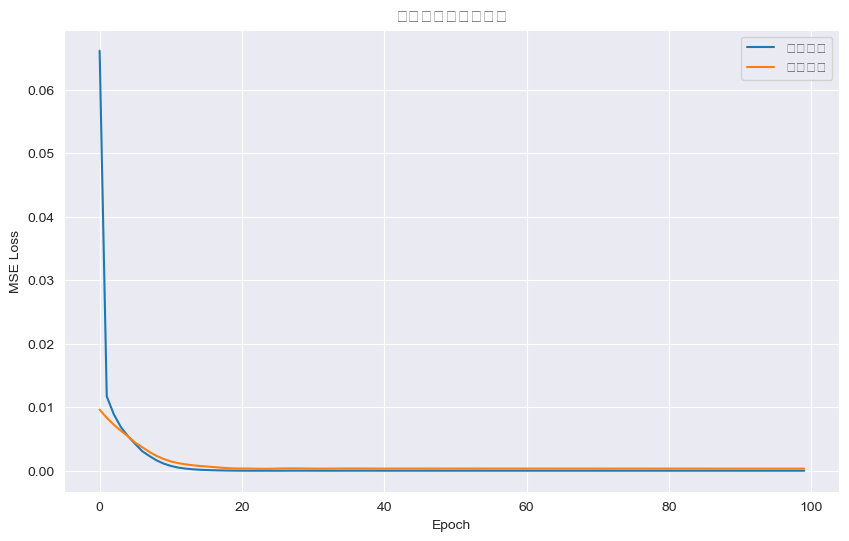

C:\Users\Ye Guiren\AppData\Local\Temp\ipykernel_28572\2799124247.py:36: UserWarning: Glyph 24490 (\N{CJK UNIFIED IDEOGRAPH-5FAA}) missing from font(s) Arial.
  plt.savefig(os.path.join(config['save_fig_dir'], f'{config["target_battery"]}_prediction.jpg'))
C:\Users\Ye Guiren\AppData\Local\Temp\ipykernel_28572\2799124247.py:36: UserWarning: Glyph 29615 (\N{CJK UNIFIED IDEOGRAPH-73AF}) missing from font(s) Arial.
  plt.savefig(os.path.join(config['save_fig_dir'], f'{config["target_battery"]}_prediction.jpg'))
C:\Users\Ye Guiren\AppData\Local\Temp\ipykernel_28572\2799124247.py:36: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) Arial.
  plt.savefig(os.path.join(config['save_fig_dir'], f'{config["target_battery"]}_prediction.jpg'))
C:\Users\Ye Guiren\AppData\Local\Temp\ipykernel_28572\2799124247.py:36: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.savefig(os.path.join(config['save_fig_dir'], f'{config["target_batte

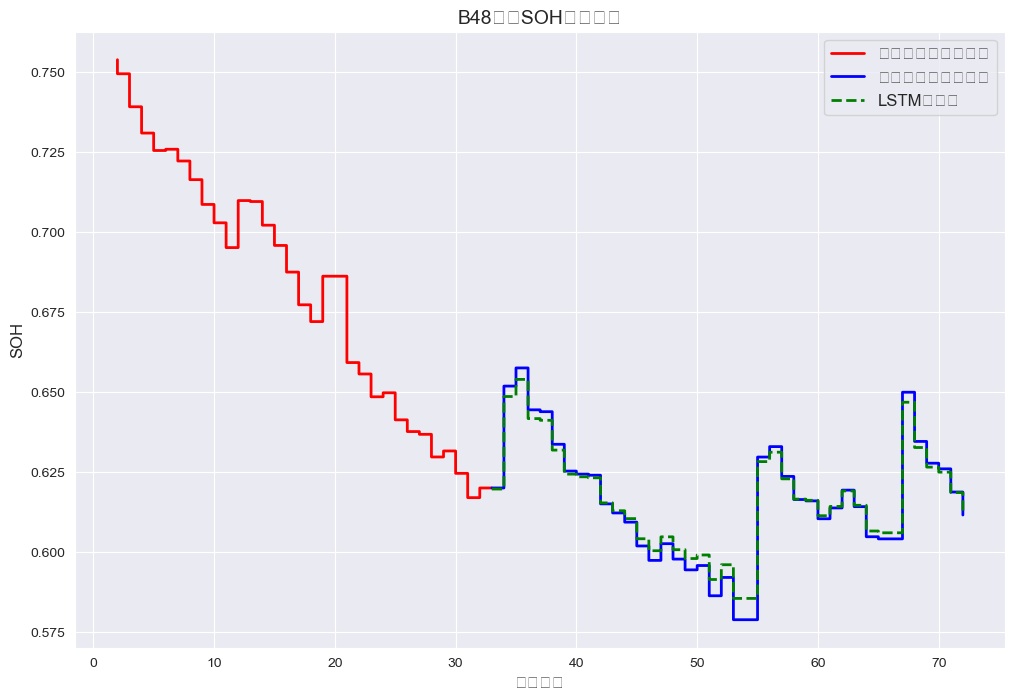

In [91]:
def plot_results(cycle_series, X_train, y_train, y_test, y_pred, scaler, config):
    """可视化损失曲线和预测结果"""
    # 1. 绘制训练/验证损失曲线
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='训练损失')
    plt.plot(val_losses, label='验证损失')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('训练与验证损失曲线')
    plt.legend()
    plt.savefig(os.path.join(config['save_fig_dir'], 'loss_curve.jpg'))
    plt.show()
    
    # 2. 绘制SOH预测对比图
    # 提取训练集、测试集对应的循环次数（确保索引匹配）
    look_back = config['look_back']
    train_size = len(X_train)
    # 训练数据对应的循环次数（前train_size个时序窗口的起始点）
    cycle_train = cycle_series[:train_size]
    # 测试数据对应的循环次数（时序窗口的起始点+look_back）
    cycle_test = cycle_series[train_size + look_back : train_size + look_back + len(y_test)]
    
    # 反归一化训练数据（用于可视化）
    y_train_true = scaler.inverse_transform(processed_data['y_train'].numpy().reshape(-1, 1)).squeeze()
    
    # 绘图
    sns.set_style("darkgrid")
    plt.figure(figsize=(12, 8))
    plt.plot(cycle_train, y_train_true, label='训练数据（真实值）', color='red', linewidth=2)
    plt.plot(cycle_test, y_true, label='测试数据（真实值）', color='blue', linewidth=2)
    plt.plot(cycle_test, y_pred, label='LSTM预测值', color='green', linewidth=2, linestyle='--')
    plt.xlabel('循环次数', fontsize=12)
    plt.ylabel('SOH', fontsize=12)
    plt.title(f'{config["target_battery"]}电池SOH预测结果', fontsize=14)
    plt.legend(prop={'size': 12})
    plt.savefig(os.path.join(config['save_fig_dir'], f'{config["target_battery"]}_prediction.jpg'))
    plt.show()
    
    # 验证循环次数与数据长度匹配（避免绘图错误）
    assert len(cycle_train) == len(y_train_true), "训练循环次数与数据长度不匹配"
    assert len(cycle_test) == len(y_true), "测试循环次数与真实值长度不匹配"
    assert len(cycle_test) == len(y_pred), "测试循环次数与预测值长度不匹配"

# 可视化结果
plot_results(
    cycle_series=processed_data['cycle_series'],
    X_train=processed_data['X_train'],
    y_train=processed_data['y_train'],
    y_test=processed_data['y_test'],
    y_pred=y_pred,
    scaler=processed_data['scaler'],
    config=config
)